In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))

In [2]:
%load_ext autoreload
%autoreload 2

import ipywidgets as widgets
import numpy as np
import os
import pandas as pd
import seaborn as sns

from benchmarks import gsa_svm_fitness
from src.entities import GSA
from src.ABC import ABC

from IPython.display import display
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from typing import Mapping, Tuple, Union
from ucimlrepo import fetch_ucirepo

In [3]:
uci_datasets = ["Breast Cancer Wisconsin (Diagnostic)",
                "Spambase",
                "Mushroom"]

widget_opt = widgets.Dropdown(
    options=uci_datasets,
    description='Dataset: '
)

display(widget_opt)

Dropdown(description='Dataset: ', options=('Breast Cancer Wisconsin (Diagnostic)', 'Spambase', 'Mushroom'), va…

In [18]:
def fetch_categorical_dataset(_id: int) -> Tuple[pd.DataFrame, pd.Series]:
    data = fetch_ucirepo(id=_id)
    X = data.data.features.copy()
    y = data.data.targets
    encoder = LabelEncoder()
    for col in X.columns:
        X[col] = encoder.fit_transform(X[col])
    return X, y

if widget_opt.value == "Breast Cancer Wisconsin (Diagnostic)":
    data = fetch_ucirepo(id=15)
    X = data.data.features
    y = data.data.targets
    X = X.fillna(value=0)
elif widget_opt.value == "Spambase":
    X, y = fetch_categorical_dataset(_id=94)
elif widget_opt.value == "Mushroom":
    X, y = fetch_categorical_dataset(_id=73)
    
# Name of selected dataset and summary (number of instances, features, etc.)
print(f"Dataset: {widget_opt.value}")
print(f"Instances: {X.shape[0]} (Train / Test: 80% / 20%)")
print(f"Features: {X.shape[1]}")

Dataset: Spambase
Instances: 4601 (Train / Test: 80% / 20%)
Features: 57


In [19]:
# WARNING!! GLOBAL VARIABLES
wa = 0.8
wf = 0.2

# IMPORTANT!! MUTABLE GLOBAL VARIABLE
conf_matrix_dict = {"TP": 0, "FP": 0, "TN": 0, "FN": 0}

class UCI:
    """
    Class to handle UCI datasets
    
    Args:
        X (pd.DataFrame): Features
        y (pd.Series): Target
    """
    def __init__(self,
                 X: pd.DataFrame,
                 y: pd.Series,
                 boundaries: Mapping[str, Tuple[Tuple[float, float], ...]],
                 seed: int = 5
                 ) -> None:
        """
        Constructor
        
        Args:
            X (pd.DataFrame): Features
            y (pd.Series): Target
            boundaries (Mapping[str, Tuple[Tuple[float, float], ...]): Boundaries for the optimization problem
            seed (int, optional): Random seed. Defaults to 5.
        """
        self.X = X
        self.y = y
        self.boundaries = boundaries

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(self.X)
        
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.20, random_state=seed)
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test

    
    def get_fitness(self,
                    solution: Mapping[str, np.ndarray],
                    data: Union[None, Tuple[np.ndarray, np.ndarray]] = None,
                    show_confusion_matrix: bool=False
                    ) -> Tuple[float, float]:
        """
        Get fitness of a solution
        
        Args:
            solution (Mapping[str, np.ndarray]): Solution to evaluate
            data (Union[None, Tuple[np.ndarray, np.ndarray]], optional): Data to evaluate the solution. Defaults to None.
        
        Returns:
            Tuple[float, float]: Fitness and accuracy of the solution    
        """
        if data is None:
            X_scaled = self.X_train
            y_data = self.y_train
        else:
            X_scaled, y_data = data
            
        gamma, C = solution['real']
        gamma /= 1_000
        C /= 1_000
        X_scaled_filtered = X_scaled[:, solution['discrete'].astype(int) == 1]
        svc_model = SVC(gamma=gamma, C=C, kernel="rbf", verbose=False)
        svc_model.fit(X_scaled_filtered, np.ravel(y_data))
        y_predict = svc_model.predict(X_scaled_filtered)
        conf_matrix = confusion_matrix(y_data, y_predict)
        if show_confusion_matrix:
            # Update global conf_matrix_dict
            conf_matrix_dict["TP"] = conf_matrix[0, 0]
            conf_matrix_dict["FP"] = conf_matrix[0, 1]
            conf_matrix_dict["TN"] = conf_matrix[1, 1]
            conf_matrix_dict["FN"] = conf_matrix[1, 0]
            print(conf_matrix)
        accuracy = accuracy_score(y_data, y_predict) * 100
        
        return gsa_svm_fitness(accuracy=accuracy, solution=solution, wa=wa, wf=wf)

    def is_feasible(self, solution: Mapping[str, np.ndarray]) -> bool:
        """
        Check if a solution is feasible

        Args:
            solution (Mapping[str, np.ndarray]): Solution to evaluate

        Returns:
            bool: True if the solution is feasible, False otherwise
        """
        real_values = solution['real']
        discrete_values = solution['discrete']

        for i, (min_val, max_val) in enumerate(self.boundaries['real']):
            if real_values[i] < min_val or real_values[i] > max_val:
                return False

        for i, (min_val, max_val) in enumerate(self.boundaries['discrete']):
            if discrete_values[i] < min_val or discrete_values[i] > max_val:
                return False
        
        if sum(discrete_values) == 0:
            return False
        
        return True

boundaries = {'real': [(1, 100_000), (1, 100_000)], 'discrete': [(0, 1) for _ in range(len(X.columns))]}
uci_data = UCI(X, y, boundaries)

In [20]:
def run_abc(uci_data : UCI,
            repair_solution: bool=False,
            runs: int=10,
            population_size: int=5,
            iterations: int=20) -> Tuple[pd.DataFrame, pd.DataFrame]:
    
    global_train_hist = pd.DataFrame()
    global_test_hist = pd.DataFrame(columns=["run", "accuracy", "fitness", "TP", "FP", "TN", "FN"])
    
    for k in range(runs):
        abc_algo = ABC(objective_function = uci_data.get_fitness,
                       is_feasible=uci_data.is_feasible,
                       r_dim=2,
                       d_dim=len(X.columns),
                       boundaries=uci_data.boundaries, limit=5)
        
        training_history = abc_algo.optimize(population_size=population_size,
                                             iters=iterations,
                                             repair_solution=repair_solution)
        
        training_history.insert(0, "run", k)
        global_train_hist = pd.concat([global_train_hist, training_history], axis=0)
        
        print(abc_algo.solution_history[-1])
        fitness, accuracy = uci_data.get_fitness(solution=abc_algo.solution_history[-1],
                                            data=(uci_data.X_test, uci_data.y_test),
                                            show_confusion_matrix=True)
        
        global_test_hist.loc[len(global_test_hist)] = [k, accuracy, fitness, conf_matrix_dict["TP"], conf_matrix_dict["FP"], conf_matrix_dict["TN"], conf_matrix_dict["FN"]]
        
        print("Test accuracy: ", accuracy, " - Fitness: ", fitness)
    
    return global_train_hist, global_test_hist

In [21]:
train_df = pd.DataFrame()
test_df = pd.DataFrame()


tr_df, tt_df = run_abc(uci_data,
                            runs=10,
                            population_size=5,
                            iterations=20)
    

train_df = pd.concat([train_df, tr_df], axis=0)
test_df = pd.concat([test_df, tt_df], axis=0)

# 1. Guardar el histórico de entrenamiento (curva de convergencia)
train_df.to_csv('../data/output/abc_train_history.csv', index=False)

# 2. Guardar los resultados finales de test (métricas por cada run)
test_df.to_csv('../data/output/abc_test_results.csv', index=False)

print("¡DataFrames guardados con éxito en archivos CSV!")

test_df

ABC is optimizing  "get_fitness"
At iteration 1 the best fitness is 92.06331045003816
At iteration 2 the best fitness is 92.06331045003816
At iteration 3 the best fitness is 92.72158657513349
At iteration 4 the best fitness is 92.72158657513349
At iteration 5 the best fitness is 93.07246376811594
At iteration 6 the best fitness is 93.07246376811594
At iteration 7 the best fitness is 93.4233409610984
At iteration 8 the best fitness is 93.4233409610984
At iteration 9 the best fitness is 93.4233409610984
At iteration 10 the best fitness is 93.4233409610984
At iteration 11 the best fitness is 93.4233409610984
At iteration 12 the best fitness is 93.4233409610984
At iteration 13 the best fitness is 93.4233409610984
At iteration 14 the best fitness is 93.4233409610984
At iteration 15 the best fitness is 93.4233409610984
At iteration 16 the best fitness is 93.4233409610984
At iteration 17 the best fitness is 93.4233409610984
At iteration 18 the best fitness is 93.4233409610984
At iteration 19 

,run,accuracy,fitness,TP,FP,TN,FN
0,0.0,99.891422,93.597348,575.0,0.0,345.0,1.0
1,1.0,99.782845,91.054346,575.0,0.0,344.0,2.0
2,2.0,99.348534,94.215669,575.0,0.0,340.0,6.0
3,3.0,99.891422,91.141208,574.0,1.0,346.0,0.0
4,4.0,99.782845,94.563118,575.0,0.0,344.0,2.0
5,5.0,99.891422,93.597348,575.0,0.0,345.0,1.0
6,6.0,100.000000,94.385965,575.0,0.0,346.0,0.0
7,7.0,99.891422,93.246471,575.0,0.0,345.0,1.0
8,8.0,100.000000,94.385965,575.0,0.0,346.0,0.0
9,9.0,100.000000,92.631579,575.0,0.0,346.0,0.0


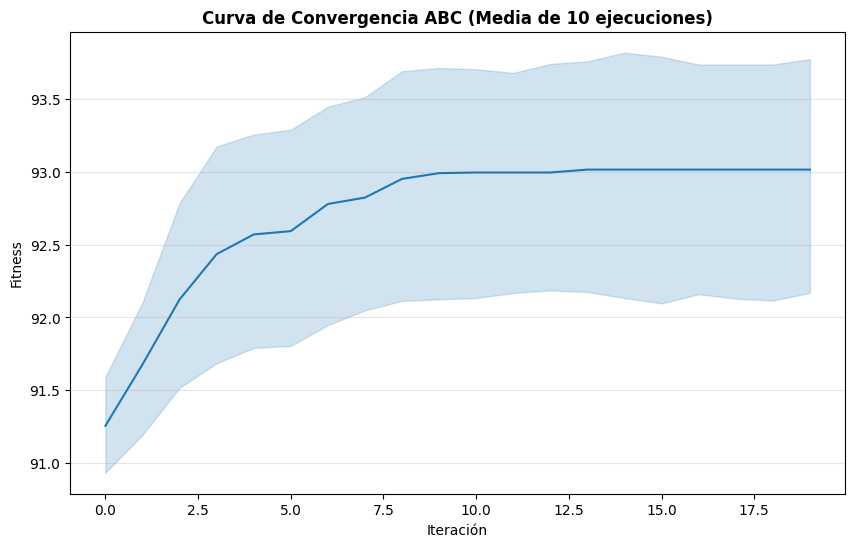

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Curva de Convergencia ABC (Media de 10 ejecuciones)", fontweight='bold')

sns.lineplot(ax=ax,
             data=train_df,
             x="Iteration",
             y="Fitness") # Eliminamos el parámetro 'hue'

ax.grid(axis='y', color='#A9A9A9', alpha=0.3, zorder=1)
ax.set_xlabel("Iteración")
ax.set_ylabel("Fitness")

plt.show()

In [23]:
# 1. Agrupamos por 'run' y cogemos la última iteración de cada ejecución
ultimas_iteraciones = train_df.groupby('run').last()

# 2. Calculamos media y desviación típica de la columna 'Accuracy' (Train)
mean_train_acc = ultimas_iteraciones['Accuracy'].mean()
std_train_acc = ultimas_iteraciones['Accuracy'].std()

# 3. Y para el Test (que ese sí está en tu test_df)
mean_test_acc = test_df['accuracy'].mean()
std_test_acc = test_df['accuracy'].std()

print("="*50)
print("RESULTADOS FINALES DEL ABC (10 ejecuciones)")
print("="*50)
print(f"Precisión en Entrenamiento (Train): {mean_train_acc:.2f}% ± {std_train_acc:.2f}%")
print(f"Precisión en Pruebas (Test):        {mean_test_acc:.2f}% ± {std_test_acc:.2f}%")
print("-"*50)

RESULTADOS FINALES DEL ABC (10 ejecuciones)
Precisión en Entrenamiento (Train): 99.51% ± 0.21%
Precisión en Pruebas (Test):        99.85% ± 0.19%
--------------------------------------------------


In [24]:
import numpy as np

# 1. Agrupamos el histórico de entrenamiento por la columna 'run' (ejecución)
# y nos quedamos solo con la última fila de cada ejecución (la iteración final)
ultimas_iteraciones = train_df.groupby('run').last()

# 2. Aplicamos np.sum a la columna 'Discrete' para contar cuántos "unos" 
# tiene la mejor abeja de cada una de las 10 ejecuciones
features_por_run = ultimas_iteraciones['Discrete'].apply(np.sum)

# 3. Calculamos la media y la desviación estándar
mean_features = features_por_run.mean()
std_features = features_por_run.std()

mean_features_rounded = round(mean_features)
std_features_rounded = round(std_features)

# Supongo que d_dim es 9 (para Breast Cancer) o el valor correspondiente a tu dataset
total_features = len(ultimas_iteraciones['Discrete'].iloc[0]) 

print(f"Media de características usadas: {mean_features_rounded} ± {std_features_rounded} (de un total de {total_features} posibles)")

Media de características usadas: 19 ± 4 (de un total de 57 posibles)
